# Phase 2 — The threshold baseline

The number every later model has to beat.

This detector does not learn. It watches one feature — `log_ratio`, how far
flux sits above the causal background — and fires when it crosses a threshold.
That is the entire model.

**Why bother?** Because a score means nothing without a reference. If a
Transformer scores 0.72 TSS in Phase 3, that is only impressive if a single
threshold scores 0.55. If the threshold scores 0.70, the network bought two
points of skill for a thousandfold jump in complexity — and a reviewer will ask.
The baseline is what makes every later result interpretable.

**Two tasks, scored separately:**
- **detection** — is a flare in progress now? (`y_progress`)
- **early warning** — will an M+ flare peak within the horizon? (`y_warn`)

Everything is chosen on validation and reported once on test, with the event
count beside every number.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("../data") if Path("../data").exists() else Path("data")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
POS, NEG, LINE = "#c0392b", "#95a5a6", "#2c7fb8"

z = np.load(DATA / "dataset.npz", allow_pickle=False)
FEATURES = [str(f) for f in z["features"]]
X = z["X"]                                   # (N, T, F), already scaled

is_tr, is_va, is_te = z["is_train"], z["is_val"], z["is_test"]
event_id = z["event_id"]

print(f"windows {len(X):,}   features {FEATURES}")
print(f"train {is_tr.sum():,}  val {is_va.sum():,}  test {is_te.sum():,}")

windows 107,173   features ['log_xrsb', 'log_xrsa', 'log_ratio', 'hardness', 'rate_smooth', 'rate_a']
train 75,070  val 16,035  test 16,008


## 1. Reduce each window to one number

The feature array is scaled (mean 0, std 1), which is what a neural net wants
but not what a threshold rule wants — a cutoff should be interpretable. So we
undo the scaling on the one feature we use and take the value at the **last**
timestep of each window: the "now" moment the label describes.

Using only the final timestep keeps this strictly causal and directly
comparable to what a live detector would see.

In [2]:
f_idx = FEATURES.index("log_ratio")
mu = z["scaler_mean"][f_idx]
sd = z["scaler_std"][f_idx]

# last timestep, un-scaled back to real log_ratio units
score_all = X[:, -1, f_idx] * sd + mu

# rate at the last step — used later for a two-feature variant
r_idx = FEATURES.index("rate_smooth")
rate_all = X[:, -1, r_idx] * z["scaler_std"][r_idx] + z["scaler_mean"][r_idx]

print(f"log_ratio at window end: min {score_all.min():.2f}, "
      f"median {np.median(score_all):.2f}, max {score_all.max():.2f}")
print("(0 = at background, 0.30 ~ 2x background, 1.0 = 10x background)")

log_ratio at window end: min -0.12, median 0.07, max 2.27
(0 = at background, 0.30 ~ 2x background, 1.0 = 10x background)


## 2. The metrics — and why not accuracy

At 1% positives, a detector that says "no flare, ever" scores 99% accuracy and
is useless. The space-weather field uses skill scores that reward catching the
rare event:

- **TSS** = TPR − FPR (True Skill Statistic / Peirce). 0 = no skill, 1 = perfect,
  and it is insensitive to how rare the positive is.
- **HSS** (Heidke) = skill above random guessing, which *is* sensitive to base
  rate, so the pair together tells you more than either alone.

Both are computed from the confusion matrix, so we build that first.

In [3]:
def confusion(y_true, y_pred):
    tp = int(np.sum((y_pred == 1) & (y_true == 1)))
    fp = int(np.sum((y_pred == 1) & (y_true == 0)))
    fn = int(np.sum((y_pred == 0) & (y_true == 1)))
    tn = int(np.sum((y_pred == 0) & (y_true == 0)))
    return tp, fp, fn, tn


def scores(y_true, y_pred):
    tp, fp, fn, tn = confusion(y_true, y_pred)
    tpr = tp / (tp + fn) if (tp + fn) else 0.0          # recall / hit rate
    fpr = fp / (fp + tn) if (fp + tn) else 0.0          # false-alarm rate
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    tss = tpr - fpr

    n = tp + fp + fn + tn
    # Heidke skill score
    num = 2 * (tp * tn - fp * fn)
    den = (tp + fn) * (fn + tn) + (tp + fp) * (fp + tn)
    hss = num / den if den else 0.0

    return {"TSS": tss, "HSS": hss, "recall": tpr, "FPR": fpr,
            "precision": prec, "tp": tp, "fp": fp, "fn": fn, "tn": tn}


# quick self-check on trivial cases
_yt = np.array([0, 0, 1, 1])
assert abs(scores(_yt, _yt)["TSS"] - 1.0) < 1e-9          # perfect -> 1
assert abs(scores(_yt, np.zeros(4, int))["TSS"]) < 1e-9   # all-negative -> 0
print("metric self-check passed: perfect=1.0, all-negative=0.0")

metric self-check passed: perfect=1.0, all-negative=0.0


## 3. Detection — sweep the threshold on TRAIN, pick on VAL

Fit nothing on test. Sweep candidate thresholds, look at how TSS behaves, choose
the value that maximises TSS on **validation**, and only then touch test.

In [4]:
y_prog = z["y_progress"]

grid = np.linspace(score_all.min(), score_all.max(), 200)


def sweep(mask, target, feature=score_all):
    yt = target[mask]
    fv = feature[mask]
    return np.array([scores(yt, (fv >= t).astype(int))["TSS"] for t in grid])


tss_tr = sweep(is_tr, y_prog)
tss_va = sweep(is_va, y_prog)

best_i = int(np.argmax(tss_va))               # choose on validation
thr = grid[best_i]
print(f"best threshold (val): log_ratio >= {thr:.3f}")
print(f"  = flux at {10**thr:.2f}x background")
print(f"  val TSS {tss_va[best_i]:.3f}   train TSS {tss_tr[best_i]:.3f}")

best threshold (val): log_ratio >= 0.111
  = flux at 1.29x background
  val TSS 0.410   train TSS 0.225


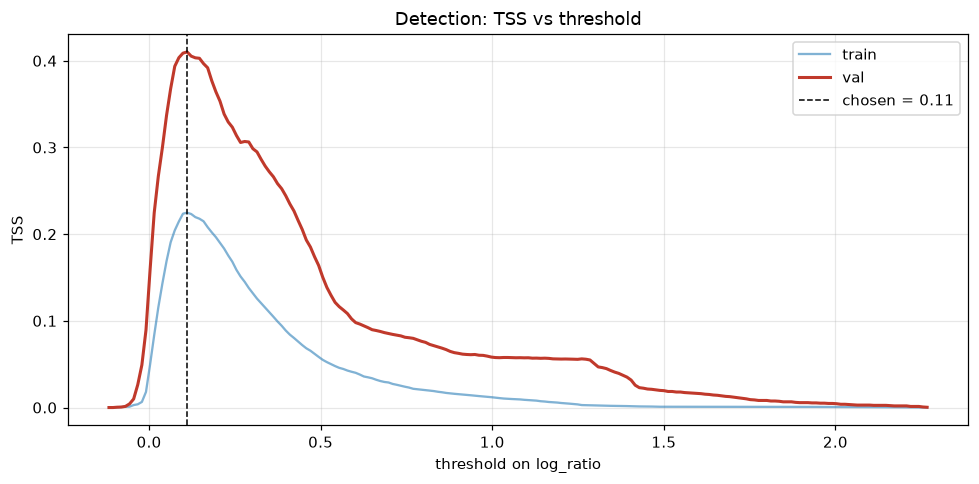

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(grid, tss_tr, color=LINE, lw=1.5, label="train", alpha=0.6)
ax.plot(grid, tss_va, color=POS, lw=2, label="val")
ax.axvline(thr, color="black", ls="--", lw=1, label=f"chosen = {thr:.2f}")
ax.set_xlabel("threshold on log_ratio")
ax.set_ylabel("TSS")
ax.set_title("Detection: TSS vs threshold")
ax.legend()
plt.tight_layout(); plt.show()

If the train and val curves peak at very different thresholds, the single
feature is not stable and a learned model has real room to improve. If they
agree, `log_ratio` alone already captures most of the detection signal — a
finding worth stating either way.

## 4. Detection — the one honest test evaluation

Threshold fixed on validation. This is the number Phase 3 must beat.

In [6]:
det = scores(y_prog[is_te], (score_all[is_te] >= thr).astype(int))
print("DETECTION on test  (flare in progress)")
for k in ["TSS", "HSS", "recall", "FPR", "precision"]:
    print(f"  {k:<10} {det[k]:.3f}")
print(f"  confusion  tp={det['tp']}  fp={det['fp']}  fn={det['fn']}  tn={det['tn']}")

DETECTION on test  (flare in progress)
  TSS        0.432
  HSS        0.344
  recall     0.730
  FPR        0.298
  precision  0.422
  confusion  tp=2682  fp=3673  fn=993  tn=8660


## 5. Early warning — the harder task

Now the task that delivers your pitch: fire *before* an M+ flare peaks. The
label is `y_warn`, roughly 1% positive, so this is where a dumb threshold should
struggle and a learned model should earn its keep.

A single threshold on current brightness is a weak warning rule almost by
definition — high flux means the flare is already here, not coming. So a
two-feature variant is also tried: brightness rising (`log_ratio`) *and* rising
fast (`rate_smooth`). Whichever wins on validation is reported on test.

In [7]:
y_warn = z["y_warn"]

# variant A: log_ratio alone
tss_va_A = sweep(is_va, y_warn)
iA = int(np.argmax(tss_va_A)); thrA = grid[iA]

# variant B: require both log_ratio >= t1 AND rate_smooth >= t2
r_grid = np.linspace(np.percentile(rate_all, 50), np.percentile(rate_all, 99), 40)
best = (-1, None, None)
for t1 in grid[::2]:
    for t2 in r_grid:
        pred = ((score_all[is_va] >= t1) & (rate_all[is_va] >= t2)).astype(int)
        s = scores(y_warn[is_va], pred)["TSS"]
        if s > best[0]:
            best = (s, t1, t2)
_, t1B, t2B = best

print(f"variant A  log_ratio >= {thrA:.3f}                 val TSS {tss_va_A[iA]:.3f}")
print(f"variant B  log_ratio >= {t1B:.3f} AND rate >= {t2B:.4f}   val TSS {best[0]:.3f}")

if best[0] > tss_va_A[iA]:
    warn_pred_te = ((score_all[is_te] >= t1B) & (rate_all[is_te] >= t2B)).astype(int)
    chosen = f"log_ratio>={t1B:.2f} AND rate>={t2B:.3f}"
else:
    warn_pred_te = (score_all[is_te] >= thrA).astype(int)
    chosen = f"log_ratio>={thrA:.2f}"
print(f"chosen on val: {chosen}")

variant A  log_ratio >= 0.231                 val TSS 0.572
variant B  log_ratio >= 0.147 AND rate >= 0.0000   val TSS 0.711
chosen on val: log_ratio>=0.15 AND rate>=0.000


In [8]:
wr = scores(y_warn[is_te], warn_pred_te)
print("EARLY WARNING on test  (M+ flare within horizon)")
for k in ["TSS", "HSS", "recall", "FPR", "precision"]:
    print(f"  {k:<10} {wr[k]:.3f}")
print(f"  confusion  tp={wr['tp']}  fp={wr['fp']}  fn={wr['fn']}  tn={wr['tn']}")

EARLY WARNING on test  (M+ flare within horizon)
  TSS        0.782
  HSS        0.122
  recall     0.883
  FPR        0.101
  precision  0.074
  confusion  tp=128  fp=1606  fn=17  tn=14257


## 6. Event-level recall — the number that goes in the report

Window-level recall double-counts: one flare is ~30 windows. What a forecaster
actually cares about is *how many distinct flares did we catch at all* — one
correct window inside an event means the event was caught.

This is reported with a Wilson interval, because at 30-odd events the point
estimate alone would overstate the precision.

In [9]:
def wilson(k, n, zc=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    d = 1 + zc*zc/n
    c = (p + zc*zc/(2*n)) / d
    h = zc*np.sqrt(p*(1-p)/n + zc*zc/(4*n*n)) / d
    return max(0.0, c-h), min(1.0, c+h)


def event_recall(mask, y_true, y_pred):
    ev = event_id[mask]
    yt = y_true[mask]
    yp = y_pred                         # already subset to the test rows
    caught = tot = 0
    for e in np.unique(ev[ev >= 0]):
        sel = ev == e
        if yt[sel].max() == 0:          # not a positive event for this task
            continue
        tot += 1
        caught += int(yp[sel].max() == 1)   # any correct window = caught
    return caught, tot


det_pred_te = (score_all[is_te] >= thr).astype(int)
ck, cn = event_recall(is_te, y_prog, det_pred_te)
lo, hi = wilson(ck, cn)
print(f"DETECTION  events caught {ck}/{cn}  = {ck/cn:.0%}  95% CI [{lo:.0%}, {hi:.0%}]")

wk, wn = event_recall(is_te, y_warn, warn_pred_te)
if wn:
    lo, hi = wilson(wk, wn)
    print(f"WARNING    events caught {wk}/{wn}  = {wk/wn:.0%}  95% CI [{lo:.0%}, {hi:.0%}]")
print()
print("Quote the event count beside every figure. n is small; the interval is honest.")

DETECTION  events caught 117/117  = 100%  95% CI [97%, 100%]
WARNING    events caught 29/29  = 100%  95% CI [88%, 100%]

Quote the event count beside every figure. n is small; the interval is honest.


## 7. The baseline, in one table

In [10]:
print(f"{'task':<12}{'TSS':>7}{'HSS':>7}{'recall':>8}{'precision':>11}{'events':>16}")
print("-" * 61)
print(f"{'detection':<12}{det['TSS']:>7.3f}{det['HSS']:>7.3f}"
      f"{det['recall']:>8.3f}{det['precision']:>11.3f}{f'{ck}/{cn}':>16}")
print(f"{'warning':<12}{wr['TSS']:>7.3f}{wr['HSS']:>7.3f}"
      f"{wr['recall']:>8.3f}{wr['precision']:>11.3f}{f'{wk}/{wn}':>16}")
print()
print("These are the numbers to beat. A learned model that does not clear the")
print("detection TSS is not earning its complexity. The warning TSS is the one")
print("that matters for the pitch -- that is where the two X-ray channels and a")
print("temporal model should pull ahead of a static threshold.")

task            TSS    HSS  recall  precision          events
-------------------------------------------------------------
detection     0.432  0.344   0.730      0.422         117/117
warning       0.782  0.122   0.883      0.074           29/29

These are the numbers to beat. A learned model that does not clear the
detection TSS is not earning its complexity. The warning TSS is the one
that matters for the pitch -- that is where the two X-ray channels and a
temporal model should pull ahead of a static threshold.


## 8. What this establishes, and Phase 3

You now have a reference. Interpreting Phase 3 becomes simple: **beat the
detection TSS comfortably, and beat the warning TSS by a margin that justifies a
neural network.**

Read the two results against each other. Detection TSS is usually high — flux
above background is nearly the definition of a flare, so a threshold does well
and a model can only edge it. Warning TSS is usually low — a static threshold
cannot see a flare *coming*, only one that has *arrived*. That gap is precisely
the room a temporal model (and, later, HEL1OS hard X-rays) exists to fill.

**Phase 3** is the learned models: 1D CNN, TCN, LSTM, Transformer, on this same
split, with walk-forward validation to widen the effective test size beyond the
30 M+ events you have here. Each is measured against this table.